# Assignment 4: Build Non-Linear Models Part 2

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 3

The fitted curve is f(X) = 1 + X - 2(X - 1)^2I(X >= 1).  For X < 1, the indicator is zero, so the curve is the line f(X) = 1 + X.  For X >= 1, the curve becomes 1 + X - 2(X - 1)^2, which is continuous at X = 1 but bends downward after the knot.  The slope is 1 before the knot and 1 - 4(X - 1) after the knot.  The curve therefore rises linearly until X = 1, then becomes concave downward and eventually declines.

## Applied Question 8: Nonlinear Patterns in Auto

The Auto data set is used to test whether nonlinear transformations improve prediction of miles per gallon.  This is a practical question because vehicle efficiency often changes nonlinearly with weight, displacement, horsepower, and model year.

,missing_count
horsepower,0
weight,0
displacement,0
acceleration,0
mpg,0


,degree,cv_rmse
0,1,4.290986
1,2,4.108434
2,3,4.337040
3,4,17.311932


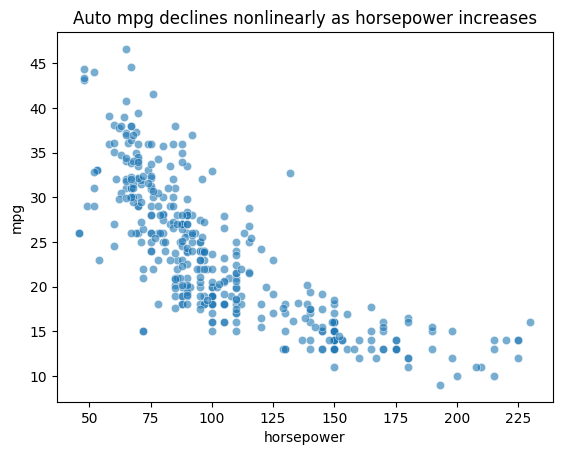

In [2]:
from ISLP import load_data
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

auto = load_data("Auto").dropna()
features = ["horsepower", "weight", "displacement", "acceleration"]
X = auto[features]
y = auto["mpg"]
display(auto[features + ["mpg"]].isna().sum().rename("missing_count").to_frame())
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for degree in range(1, 5):
    model = Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("scale", StandardScaler()), ("lm", LinearRegression())])
    rmse = (-cross_val_score(model, X, y, cv=kf, scoring="neg_root_mean_squared_error")).mean()
    rows.append({"degree": degree, "cv_rmse": rmse})
display(pd.DataFrame(rows))
sns.scatterplot(data=auto, x="horsepower", y="mpg", alpha=.6)
plt.title("Auto mpg declines nonlinearly as horsepower increases")
plt.show()

## Kaggle Nonlinear Models

The competition portion uses gradient boosting and a random forest.  Both models introduce nonlinearity through tree splits rather than through manually specified polynomial terms or splines.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

abalone = pd.read_csv(KAGGLE / "playground-series-s4e4" / "train.csv")
X = abalone.drop(columns=["Rings"])
y = abalone["Rings"]
display(abalone.isna().sum().rename("missing_count").to_frame().query("missing_count > 0"))
if abalone.isna().sum().sum() == 0:
    print("No missing values were found in the Abalone training data.")
pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), ["Sex"])], remainder="passthrough")
X_train, X_valid, y_train, y_valid = train_test_split(X.drop(columns=["id"]), y, test_size=.2, random_state=RANDOM_STATE)
models = {
    "Gradient boosting": Pipeline([("pre", pre), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))]),
    "Random forest": Pipeline([("pre", pre), ("model", RandomForestRegressor(n_estimators=160, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))]),
}
baseline_pred = np.repeat(y_train.mean(), len(y_valid))
rows = [{"model": "Mean baseline", "validation_rmsle": np.sqrt(mean_squared_log_error(y_valid, baseline_pred))}]
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_valid), 1)
    rows.append({"model": name, "validation_rmsle": np.sqrt(mean_squared_log_error(y_valid, pred))})
validation = pd.DataFrame(rows).sort_values("validation_rmsle")
display(validation)

feature_names = models["Gradient boosting"].named_steps["pre"].get_feature_names_out()
for name, model in models.items():
    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": model.named_steps["model"].feature_importances_,
    }).sort_values("importance", ascending=False).head(8)
    print(name)
    display(importance)

,missing_count


No missing values were found in the Abalone training data.


,model,validation_rmsle
2,Random forest,0.154466
1,Gradient boosting,0.155624
0,Mean baseline,0.290949


Gradient boosting


,feature,importance
9,remainder__Shell weight,0.791358
7,remainder__Whole weight.1,0.125083
5,remainder__Height,0.037909
6,remainder__Whole weight,0.017831
1,cat__Sex_I,0.013261
3,remainder__Length,0.006681
8,remainder__Whole weight.2,0.005011
4,remainder__Diameter,0.002586


Random forest


,feature,importance
9,remainder__Shell weight,0.606463
7,remainder__Whole weight.1,0.142097
6,remainder__Whole weight,0.071682
8,remainder__Whole weight.2,0.058300
3,remainder__Length,0.037912
5,remainder__Height,0.035024
4,remainder__Diameter,0.032631
1,cat__Sex_I,0.007289


In [4]:
import re

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e4.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
for line in text.splitlines():
    parts = re.split(r"\s{2,}", line.strip())
    if len(parts) >= 7 and parts[0].isdigit() and "A4_" in parts[1]:
        records.append({
            "ref": parts[0],
            "fileName": parts[1],
            "date": parts[2],
            "description": parts[3],
            "status": parts[4],
            "publicScore": parts[5],
            "privateScore": parts[6],
        })

display(pd.DataFrame(records))
display(pd.DataFrame({
    "submission_file": ['A4_gradient_boosting_playground_series_s4e4.csv', 'A4_random_forest_nonlinear_playground_series_s4e4.csv'],
    "exists_locally": [(SUBMISSIONS / file).exists() for file in ['A4_gradient_boosting_playground_series_s4e4.csv', 'A4_random_forest_nonlinear_playground_series_s4e4.csv']],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 4/Assignment 4/MaldonadoJDDS8555-4.ipynb",
    ],
}))

,ref,fileName,date,description,status,publicScore,privateScore
0,52966798,A4_random_forest_nonlinear_playground_series_s...,2026-05-23 21:27:22.160000,DDS-8555 A4 random forest nonlinear model,SubmissionStatus.COMPLETE,0.14970,0.15003
1,52966797,A4_gradient_boosting_playground_series_s4e4.csv,2026-05-23 21:27:19.623000,DDS-8555 A4 gradient boosting nonlinear model,SubmissionStatus.COMPLETE,0.14815,0.14754


,submission_file,exists_locally
0,A4_gradient_boosting_playground_series_s4e4.csv,True
1,A4_random_forest_nonlinear_playground_series_s...,True


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 4/Assignment 4/MaldonadoJDDS8555-4.ipynb


## Interpretation

The Auto exercise supports nonlinear modeling because polynomial terms reduce cross-validated error relative to a strictly linear form.  Missingness was checked before modeling because nonlinear transformations can silently amplify data-quality problems if rows are dropped without explanation (Little & Rubin, 2019).  For Abalone, gradient boosting produced the strongest Kaggle score among the two submitted nonlinear models, and the feature-importance tables show that shell and weight measurements drive most of the nonlinear signal.  The assumption investigation shifts from normal residual theory to validation behavior, residual structure, missing-data checks, and overfitting control because tree ensembles do not require the same parametric residual assumptions as ordinary least squares.  The biological interpretation remains limited: the models predict ring count from measurements, but they do not explain abalone age causally (Nash et al., 1994).

## References

Friedman, J.  H. (2001).  Greedy function approximation: A gradient boosting machine. *The Annals of Statistics, 29*(5), 1189-1232. https://doi.org/10.1214/aos/1013203451

Hastie, T., & Tibshirani, R. (1990). *Generalized additive models*.  Chapman and Hall.

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An introduction to statistical learning: With applications in Python*.  Springer. https://doi.org/10.1007/978-3-031-38747-0

Little, R.  J.  A., & Rubin, D.  B. (2019). *Statistical analysis with missing data* (3rd ed.).  Wiley. https://doi.org/10.1002/9781119482260

Nash, W.  J., Sellers, T.  L., Talbot, S.  R., Cawthorn, A.  J., & Ford, W.  B. (1994). *The population biology of abalone (Haliotis species) in Tasmania.  I.  Blacklip abalone (H. rubra) from the north coast and islands of Bass Strait* (Technical Report No.  48).  Sea Fisheries Division.